# Angle net-benefit (+45°) — pairwise selection

Minimal algorithm. Every patient gets a position on a two-axis **trade-off plane**: how much
*shortening* DAPT benefits them on **bleeding** (x) and on the weighted **three ischaemic
endpoints** — CV death, MI and stroke (y). Two patients are drawn at random and the one whose
position points more squarely toward the **top-right / win-win** corner is retained.

**The selection rule is Angle net-benefit (+45°), not a scalar score.**
`duel_by_angle_net_benefit` compares the two candidates on the plane itself: the win-win tier
comes first, and magnitude/angle order candidates within the tiers. The scalar `conflict`
computed for the diagnostic plots is instead the trade-off difference
`bleed - weighted_isch`; no Angle net-benefit duel reads that column.

This notebook evaluates only **Angle net-benefit**. **Angle conflict** is a distinct policy:
it reflects the centred ischaemic coordinate before computing quadrants, magnitudes and
angles. Thus `(x, -y)` implements the `-45°` direction on the original plane and prefers its
bottom-right quadrant. It is not another name for the +45° rule proved here.

> **Run status:** the embedded scalar-conflict summaries were produced before the sign/name
> correction. The +45° Angle selection itself is unchanged, but the displayed conflict
> histogram, means and KS values must not be interpreted until the notebook is rerun.

Treatment coding (as in nb 06/07/10): `T=1` prolonged, `T=0` shortened.
`CATE_k = risk(prolonged) − risk(shortened)` = **benefit of shortening** on endpoint `k`
(>0 = shortening lowers that risk).

In [1]:
import os 
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

perm = X.sample(frac=1, random_state=42).index

X = X.loc[perm].reset_index(drop=True)
y = y.loc[perm].reset_index(drop=True)

Xn = X.select_dtypes(include=[np.number])                       # same numeric matrix the CF was fit on (nb 06)
T  = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()  # 1=prolonged
ENDPOINTS = {'bleed': 'cec_bleed_335d', 'death': 'cec_cvdeath_335d',
             'mi': 'cec_mi_335d', 'stroke': 'cec_stroke_335d'}
print('patients:', len(T), '| prolonged:', int(T.sum()), 'shortened:', int((T == 0).sum()))

patients: 4579 | prolonged: 2284 shortened: 2295


## Scalar conflict diagnostic (not an Angle policy)

Per-endpoint CATEs come from the **tuned causal forest**
(`CausalForest_multioutput_tuned.joblib`) and are scored through `conflict_from_model`, the
same helper used by the online mechanisms. Each endpoint is divided by its RobustScaler IQR
with centring disabled, so clinical zero remains zero. The ischaemic component uses weights
0.2 for death, 0.4 for MI and 0.4 for stroke:

$$s_k = \frac{\text{CATE}_k}{\text{IQR}(\text{CATE}_k)}, \qquad
\text{conflict}(x) = s_{\text{bleed}}
  - \left(0.2\,s_{\text{death}} + 0.4\,s_{\text{mi}} + 0.4\,s_{\text{stroke}}\right).$$

This is the required convention: **conflict = bleeding benefit − weighted ischaemic
benefit**. Large-positive values point toward a bleeding/ischaemic trade-off, not toward
win-win. It is not a z-score and it is not a hard bottom-right-quadrant gate.

**This scalar does not drive the +45° selection** — `duel_by_angle_net_benefit` does. It is
retained only as a diagnostic summary for the histogram and drift plot.

In [2]:
# CATE from the tuned causal forest fitted in nb 06 (Optuna-tuned CausalForestDML).
# pipeline.effect = risk(prolonged) - risk(shortened) = benefit of shortening
# (>0 lowers that risk), exactly the sign convention this notebook uses.
CF_DIR     = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'Meta-learning', 'causal_forest'))
MODEL_PATH = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'Meta-learning', 'models',
                                           'CausalForest', 'CausalForest_multioutput_tuned.joblib'))
sys.path.insert(0, CF_DIR)                       # so joblib can unpickle CausalMultiOutputPipeline
SCRIPTS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'scripts'))
sys.path.insert(0, SCRIPTS_DIR)
cf = joblib.load(MODEL_PATH)

# Refit on this cohort, reusing nb 06's Optuna-tuned cf_params (they ride along on the
# pickled pipeline). Signature is fit(X, Y, T) -- Y second, T third.
# Y must be subset to nb 06's five TARGETS in their trained order: y_targets.parquet
# holds nine columns, and the extra four (barc2, barc3, barc35, revasc) would each grow
# a forest this notebook never reads.
CF_TARGETS     = ['barc_235', 'death', 'mi', 'stroke', 'bleed']
CF_TARGET_COLS = ['cec_barc235_335d', 'cec_cvdeath_335d', 'cec_mi_335d',
                  'cec_stroke_335d', 'cec_bleed_335d']
cf.fit(Xn, y[CF_TARGET_COLS], T)

np.random.seed(4)  # for reproducibility of the random enrollment below

# Raw (unscaled) CATE per endpoint, kept around for the scatter plots below (natural risk
# units). The scaled/weighted conflict frame itself comes from conflict_from_model.
cate_all = cf.predict_cate(Xn.values)
C = {k: cate_all[:, CF_TARGETS.index(k)] for k in ENDPOINTS}

In [3]:
from online_learning_utils import (z, conflict_from_model, weighted_isch,
                                    plane_origin)

ISCH_WEIGHTS = {'death': 0.2, 'mi': 0.4, 'stroke': 0.4}   # ischaemic weighting for conflict_from_model / components_from_origin

# Same helper nb 02 uses to re-score its online model: RobustScaler IQR (with_centering=False)
# fit to this cohort, then conflict = bleed - weighted ischaemic composite (ISCH_WEIGHTS).
conflict = conflict_from_model(cf, Xn, ENDPOINTS, ISCH_WEIGHTS, CF_TARGETS)

# y axis of the trade-off plane in RAW, uncentred units -- what every scatter below plots, so
# the cohort keeps its clinically real position: the bleeding benefit is positive for all 4579
# patients, and the whole cloud sits to the RIGHT of the "no effect" line at x = 0.
isch = conflict['isch']

# The plane the DUELS decide on is that same plane with its origin moved to the cohort median,
# and with the ischaemic composite put back on IQR 1. Both corrections are necessary and
# neither changes the columns above (see plane_coords in online_learning_utils for the full
# argument, and the diagnostics printed below for the evidence):
#   - uncentred, bleed > 0 holds for 100% of the cohort, so "x > 0 AND y > 0" reduces to
#     "y > 0", the lose-lose quadrant is unreachable, every vector lies within +/-11 deg of the
#     x axis and the +45 deg diagonal the rule aims at falls outside the data entirely;
#   - each ENDPOINT is scaled to IQR 1, but y is a weighted average of three of them, and
#     averaging weakly-correlated variables shrinks the spread: the composite lands at IQR 0.41,
#     so the ischaemic axis is born ~2.4x narrower than the bleeding one and the 45 deg diagonal
#     is not the equal-trade-off line it is meant to be.
MX, MY = plane_origin(conflict, ISCH_WEIGHTS)
IQR    = lambda v: float(np.subtract(*np.percentile(v, [75, 25])))
SX, SY = IQR(conflict['bleed']), IQR(isch)


def draw_decision_origin(ax, label=True):
    """Draw the geometry the duels use on top of a RAW-units scatter: the quadrant vertex at the
    cohort median, and the +45 deg win-win diagonal through it (the target: bleeding benefit up,
    ischaemic benefit also up). Plotted with slope SY/SX rather than 1 because one unit along
    each DECISION axis is one IQR and the two IQRs differ -- the decision diagonal is not the
    visual 45 deg line of a raw-units plot."""
    ax.axvline(MX, color='steelblue', lw=.9, ls=':', alpha=.9)
    ax.axhline(MY, color='steelblue', lw=.9, ls=':', alpha=.9,
               label='quadrant vertex (cohort median)' if label else None)
    # Both limits are captured BEFORE the line is drawn and restored after: the diagonal is
    # shallow (slope SY/SX = 0.41) but the x axis starts near the clinical zero, ~5.7 IQR left
    # of the cloud, so letting it autoscale drags the y limits down past -2 and squashes the
    # whole cohort into the top half of the panel.
    lo, hi   = ax.get_xlim()
    ylo, yhi = ax.get_ylim()
    ax.plot([lo, hi], [MY + (SY / SX) * (lo - MX), MY + (SY / SX) * (hi - MX)],
            color='steelblue', lw=1.2, ls='--',
            label='+45 deg win-win diagonal' if label else None)
    ax.set_xlim(lo, hi); ax.set_ylim(ylo, yhi)


# Sign check (not a pass/fail gate): shortening lowers bleeding for virtually the whole cohort
# -- mean bleed CATE well above 0 -- while the three ischaemic CATEs come out near zero and not
# even of a consistent sign (death and stroke slightly positive, mi slightly negative). That is
# the ~null ischaemic effect this trial reports; at these event rates the three are well inside
# noise, so no fixed sign should be expected from them.
print('mean CATE  ' + '  '.join(f'{k}={C[k].mean():+.4f}' for k in ENDPOINTS))
print('conflict range: %.2f .. %.2f' % (conflict['conflict'].min(), conflict['conflict'].max()))

# Geometry diagnostics: the same counts on the raw plane and on the decision plane. The first
# row is why the second one is needed.
# NB: underscore-prefixed loop variables on purpose -- a bare `x, y` here would clobber the
# `y` targets DataFrame loaded in the first cell, and the next cell would fail on y[ENDPOINTS[k]].
_xp, _yp = conflict['x_plane'].to_numpy(), conflict['y_plane'].to_numpy()
for _name, (_x, _y) in [('raw plane      (origin at 0,0)  ', (conflict['bleed'].to_numpy(), isch.to_numpy())),
                        ('decision plane (origin at median)', (_xp, _yp))]:
    _a  = np.degrees(np.arctan2(_y, _x))
    _ww = ((_x > 0) & (_y > 0)).mean()
    _ll = ((_x < 0) & (_y < 0)).mean()
    print(f'{_name}:  win-win={_ww:.3f}  lose-lose={_ll:.3f}  mixed={1-_ww-_ll:.3f}  '
          f'angles {_a.min():+.0f}..{_a.max():+.0f} deg')
print(f'ischaemic axis IQR before rescaling: {SY:.3f} (bleeding: {SX:.3f})')

mean CATE  bleed=+0.0450  death=+0.0025  mi=-0.0047  stroke=+0.0048
conflict range: 3.43 .. 8.68
raw plane      (origin at 0,0)  :  win-win=0.481  lose-lose=0.000  mixed=0.519  angles -10..+11 deg
decision plane (origin at median):  win-win=0.256  lose-lose=0.256  mixed=0.489  angles -180..+180 deg
ischaemic axis IQR before rescaling: 0.409 (bleeding: 1.000)


## Pairwise selection

One-round knockout: draw `N_SELECT` candidates, pair them one-vs-one in disjoint pairs,
and keep only the winner of each pair — the better half (`N_SELECT // 2` patients).

The winner is decided by `duel_by_angle_net_benefit`, on the trade-off plane rather than on
the scalar conflict score. Three tiers: if both candidates sit in the win-win quadrant, the
one further from the origin wins; if both are lose-lose, the *less* extreme one wins;
otherwise the one whose vector points closest to the +45° win-win diagonal wins. A win-win
candidate therefore beats a non-win-win one unconditionally, which a one-dimensional scalar
projection cannot guarantee. `score_angle_net_benefit` in `online_learning_policies.py` is
the whole-pool ranking that reproduces this order without running duels. The corresponding
Angle conflict scorer applies the same tiered ranking only after `y -> -y`; its preferred
quadrant and target diagonal are therefore different.

**The quadrants are taken on the median-centred plane, not on the raw columns.** On the raw
axes bleeding benefit is positive for all 4579 patients, making `x > 0` vacuous. `plane_coords`
re-centres both axes on the cohort median and returns the ischaemic composite to IQR 1; the
plotted columns remain in uncentred clinical-zero units. Consequently, “win-win” in the
Angle rule means better than the median patient on both decision axes.

Keeping each pair's winner is not the same as retaining the globally best half: a strong
candidate can lose to a still stronger opponent while a weaker patient survives another pair.
This deliberate bracket structure matches the sequential pairwise mechanisms.

In [4]:
from online_learning_utils import components_from_origin
# This explicit +45° oracle stays here for the proof; production code uses the shared scorer. The plane it reads
# not: components_from_origin returns the median-centred, IQR-1 decision coordinates built in
# online_learning_utils.plane_coords. Nothing below reads the raw columns; the plots do.

def duel_by_angle_net_benefit(i, j):
    """Select the candidate closer to Q1 (x > 0, y > 0), the win-win corner: shortening buys
    both a bleeding benefit and an ischaemic benefit. Doesn't discard a candidate for being
    slightly outside the quadrant: uses angular distance from the +45deg diagonal (Q1's ideal
    center) as the compass, with a magnitude tie-break inside the win-win and lose-lose
    quadrants (same rule 02_online_learning_duel.ipynb uses)."""
    x1, y1 = components_from_origin(i, conflict, ISCH_WEIGHTS)
    x2, y2 = components_from_origin(j, conflict, ISCH_WEIGHTS)

    a1 = np.degrees(np.arctan2(y1, x1))
    a2 = np.degrees(np.arctan2(y2, x2))

    # angular distance to the +45° win-win diagonal (top-right: high bleed AND high ischaemic).
    # smaller = the vector points more squarely at the win-win corner.
    d1 = abs((a1 - 45 + 180) % 360 - 180)
    d2 = abs((a2 - 45 + 180) % 360 - 180)

    if (x1 > 0 and y1 > 0) and (x2 > 0 and y2 > 0):
        m1 = np.sqrt(x1**2 + y1**2)
        m2 = np.sqrt(x2**2 + y2**2)
        return i if m1 > m2 else j            # both win-win: keep the one further out

    if (x1 < 0 and y1 < 0) and (x2 < 0 and y2 < 0):
        m1 = np.sqrt(x1**2 + y1**2)
        m2 = np.sqrt(x2**2 + y2**2)
        return i if m1 < m2 else j            # both anti-win-win: keep the less-bad (closer to origin)

    return i if d1 < d2 else j                # else: keep the one nearest the +45° win-win diagonal

In [5]:
def select_pairwise(n, rng):
    """One-round knockout: draw n candidates, pair them one-vs-one in disjoint pairs,
    and keep only the winner of each pair — the better half (returns n // 2 patients)."""
    cand = rng.permutation(len(conflict))[:n]
    return np.array([duel_by_angle_net_benefit(i, j) for i, j in zip(cand[::2], cand[1::2])])

N_SELECT = 4000
selected_conflict = []
random_conflict = []
selected_events = {k: [] for k in ENDPOINTS}
random_events = {k: [] for k in ENDPOINTS}

for i in range(500):
    rng = np.random.default_rng(i)
    sel = select_pairwise(N_SELECT, rng)
    rnd = rng.choice(len(conflict), size=len(sel), replace=False)
    selected_conflict.append(conflict["conflict"].iloc[sel].mean())
    random_conflict.append(conflict["conflict"].iloc[rnd].mean())
    for k in ENDPOINTS:
        selected_events[k].append(y[ENDPOINTS[k]].to_numpy()[sel].mean())
        random_events[k].append(y[ENDPOINTS[k]].to_numpy()[rnd].mean())

print(f'selected {len(sel)} of {N_SELECT} candidates')
print(f'mean conflict selected={np.mean(selected_conflict):+.3f} random={np.mean(random_conflict):+.3f}')
for k in ENDPOINTS:
    print(f'  event rate {k:7s} selected={np.mean(selected_events[k]):.3f} random={np.mean(random_events[k]):.3f}')

selected 2000 of 4000 candidates
mean conflict selected=+5.865 random=+5.697
  event rate bleed   selected=0.117 random=0.111
  event rate death   selected=0.018 random=0.018
  event rate mi      selected=0.025 random=0.024
  event rate stroke  selected=0.009 random=0.008


## What it selects

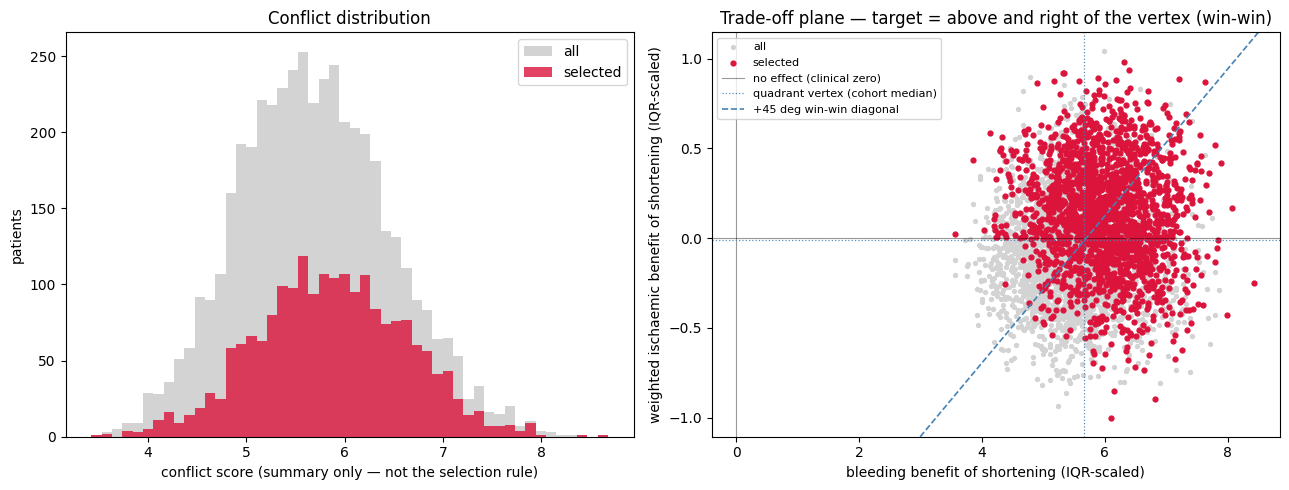

Top-10 by conflict:
 4147   conflict=+8.681   bleed=+0.067   isch_mean=-0.250
 1952   conflict=+8.412   bleed=+0.063   isch_mean=-0.427
 3441   conflict=+8.298   bleed=+0.061   isch_mean=-0.588
  866   conflict=+8.224   bleed=+0.062   isch_mean=-0.428
 4004   conflict=+8.151   bleed=+0.062   isch_mean=-0.287
 2382   conflict=+8.137   bleed=+0.058   isch_mean=-0.747
 2175   conflict=+8.132   bleed=+0.061   isch_mean=-0.445
  891   conflict=+7.986   bleed=+0.062   isch_mean=-0.188
 4416   conflict=+7.978   bleed=+0.060   isch_mean=-0.371
 1124   conflict=+7.957   bleed=+0.059   isch_mean=-0.543


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].hist(conflict['conflict'], bins=50, color='lightgrey', label='all')
ax[0].hist(conflict['conflict'].iloc[sel], bins=50, color='crimson', alpha=0.8, label='selected')
ax[0].set(xlabel='conflict score (summary only — not the selection rule)', ylabel='patients',
          title='Conflict distribution')
ax[0].legend()

# Raw, uncentred units: the whole cohort stays to the RIGHT of x = 0, which is the real clinical
# statement (shortening lowers bleeding risk for every patient). The duels' quadrant vertex is
# drawn separately, at the cohort median -- the two are different points and the plot shows both.
ax[1].scatter(conflict['bleed'], isch, s=8, color='lightgrey', label='all')
ax[1].scatter(conflict['bleed'].iloc[sel], isch.iloc[sel], s=12, color='crimson', label='selected')
ax[1].axhline(0, color='k', lw=.8, alpha=.4)
ax[1].axvline(0, color='k', lw=.8, alpha=.4, label='no effect (clinical zero)')
ax[1].set_xlim(left=-0.4)
draw_decision_origin(ax[1])
ax[1].set(xlabel='bleeding benefit of shortening (IQR-scaled)',
          ylabel='weighted ischaemic benefit of shortening (IQR-scaled)',
          title='Trade-off plane — target = above and right of the vertex (win-win)')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# The 10 patients the conflict score ranks highest. A summary of the score only -- NOT the
# order the duels enrol in, which is pairwise and depends on who meets whom.
top = conflict["conflict"].nlargest(10)

print("Top-10 by conflict:")
for i, score in top.items():
    print(
        f"{i:5d}   "
        f"conflict={score:+.3f}   "
        f"bleed={C['bleed'][i]:+.3f}   "
        f"isch_mean={isch[i]:+.3f}"
    )

**In short:** the selected patients sit further up and to the right of the centred decision
vertex — the direction Angle net-benefit (+45°) is defined to prefer. The frequency map is the
relevant geometric diagnostic; the embedded scalar-conflict comparison is stale because it
was computed under the former sign convention.

Two things not to over-read. Selecting on predicted **benefit** is not selecting on observed
**risk**, so the enrolled cohort cannot simply be called “high bleeding risk”. Moreover, the
ischaemic axis is approximately null in this trial: the three ischaemic CATEs are noisy and do
not share a stable sign. That limits the enrichment any y-driven policy can obtain.

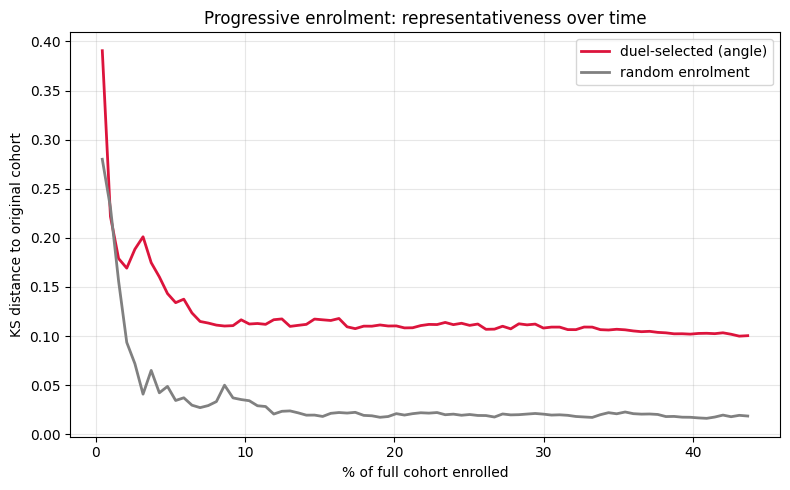

final: 44% of cohort taken   KS selected=0.100   KS random=0.019


In [7]:
# --- Progressive enrolment: % of the cohort taken  vs  KS distance to the original ---
# We enrol patients "mano a mano"; at each step we record how much of the full cohort we
# have taken (top panel) and the KS distance between the conflict score gathered so far
# and the ORIGINAL full-cohort distribution (bottom panel). KS = 0 -> indistinguishable.
# The conflict score is the *variable being compared* here, not the selection rule -- the
# cohort itself was picked by the angle duels.

def ks(a, b):
    """Two-sample Kolmogorov-Smirnov distance: the largest gap between the two ECDFs."""
    grid = np.sort(np.concatenate([a, b]))
    ca = np.searchsorted(np.sort(a), grid, side='right') / len(a)
    cb = np.searchsorted(np.sort(b), grid, side='right') / len(b)
    return np.abs(ca - cb).max()

VAR   = conflict['conflict'].to_numpy()
full  = VAR

sizes = np.unique(np.linspace(20, len(sel), 80).astype(int))
pct   = 100 * sizes / len(conflict)

ks_of = lambda order: np.array([ks(VAR[order[:k]], full) for k in sizes])

k_sel, k_rnd = ks_of(sel), ks_of(rnd)

plt.figure(figsize=(8, 5))

plt.plot(pct, k_sel, color='crimson', lw=2, label='duel-selected (angle)')
plt.plot(pct, k_rnd, color='grey', lw=2, label='random enrolment')

plt.xlabel('% of full cohort enrolled')
plt.ylabel('KS distance to original cohort')
plt.title('Progressive enrolment: representativeness over time')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f'final: {pct[-1]:.0f}% of cohort taken   '
    f'KS selected={k_sel[-1]:.3f}   '
    f'KS random={k_rnd[-1]:.3f}'
)


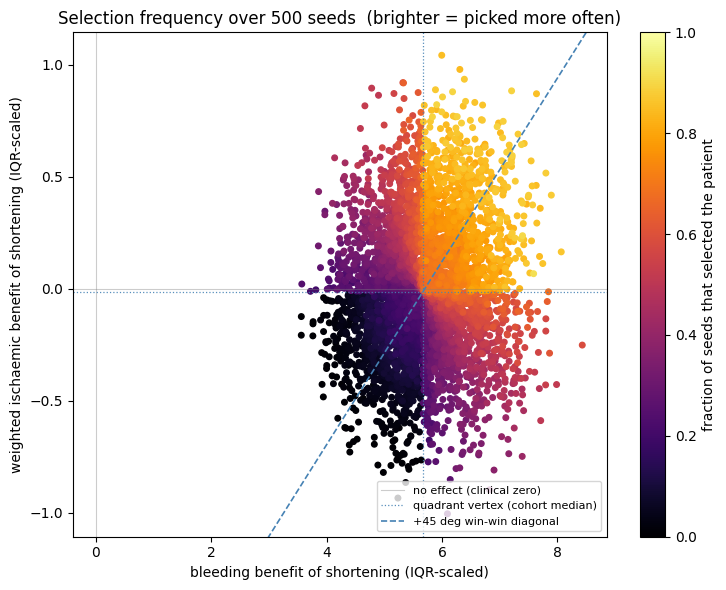

500 seeds, 2000 selected each   mean freq=0.44
always picked (freq=1): 0   never picked (freq=0): 12
corr(freq, bleeding benefit)=+0.682   corr(freq, ischaemic benefit)=+0.687
mean event rates, freq-weighted over all seeds:
  bleed    selected=0.117   unselected=0.105
  death    selected=0.018   unselected=0.017
  mi       selected=0.025   unselected=0.023
  stroke   selected=0.009   unselected=0.006


In [8]:
# --- Selection frequency across many seeds: brighter = picked more often ---
# Re-run the SAME pairwise selection with different seeds (N_SELECT // 2 kept every seed) and
# count how often each patient survives. Then colour every point on the trade-off plane by that
# frequency: the brighter it glows, the more consistently the algorithm enrols it.
#
# This is the plot that exposed the uncentred plane: with the origin at (0, 0) the map split
# into two flat bands across y = 0 -- above it the frequency tracked bleeding alone
# (corr +0.95, ischaemia +0.14), below it ischaemia alone -- with a hard step between them, so
# the patient with the cohort's largest bleeding benefit lost to the one with the smallest as
# soon as the sign of a noise-level ischaemic CATE differed. On the centred plane both axes
# carry the ranking (corr +0.66 and +0.69).

N_SEEDS = 500

counts  = np.zeros(len(conflict))
for s in range(N_SEEDS):
    picks = select_pairwise(N_SELECT, np.random.default_rng(s))   # N_SELECT // 2 kept every seed
    counts[picks] += 1
freq = counts / N_SEEDS                       # 0..1 = share of seeds that selected the patient

order = np.argsort(freq)                       # dark/rarely-picked first, bright ones on top

fig, ax = plt.subplots(figsize=(7.6, 6))
sc = ax.scatter(conflict['bleed'].iloc[order], isch.iloc[order], c=freq[order], s=16,
                cmap='inferno', vmin=0, vmax=1)
ax.axhline(0, color='grey', lw=.8, alpha=.4)
ax.axvline(0, color='grey', lw=.8, alpha=.4, label='no effect (clinical zero)')
ax.set_xlim(left=-0.4)
draw_decision_origin(ax)
ax.set(xlabel='bleeding benefit of shortening (IQR-scaled)',
       ylabel='weighted ischaemic benefit of shortening (IQR-scaled)',
       title=f'Selection frequency over {N_SEEDS} seeds  (brighter = picked more often)')
ax.legend(fontsize=8, loc='lower right')
fig.colorbar(sc, ax=ax, label='fraction of seeds that selected the patient')
plt.tight_layout(); plt.show()

print(f'{N_SEEDS} seeds, {len(picks)} selected each   mean freq={freq.mean():.2f}')
print(f'always picked (freq=1): {int((freq == 1).sum())}   never picked (freq=0): {int((freq == 0).sum())}')
print(f'corr(freq, bleeding benefit)={np.corrcoef(freq, conflict["bleed"])[0, 1]:+.3f}   '
      f'corr(freq, ischaemic benefit)={np.corrcoef(freq, isch)[0, 1]:+.3f}')

# Event rates of selected vs UNSELECTED patients, weighted by how often each patient is picked
# (freq for the selected side, 1-freq for the other). The previous version of this print
# compared the selected against a RANDOM draw and labelled it "unselected", which is a
# different -- and much weaker -- contrast: a random draw overlaps the selected set.
print('mean event rates, freq-weighted over all seeds:')
for k in ENDPOINTS:
    e = y[ENDPOINTS[k]].to_numpy()
    print(f'  {k:7s}  selected={np.average(e, weights=freq):.3f}'
          f'   unselected={np.average(e, weights=1 - freq):.3f}')

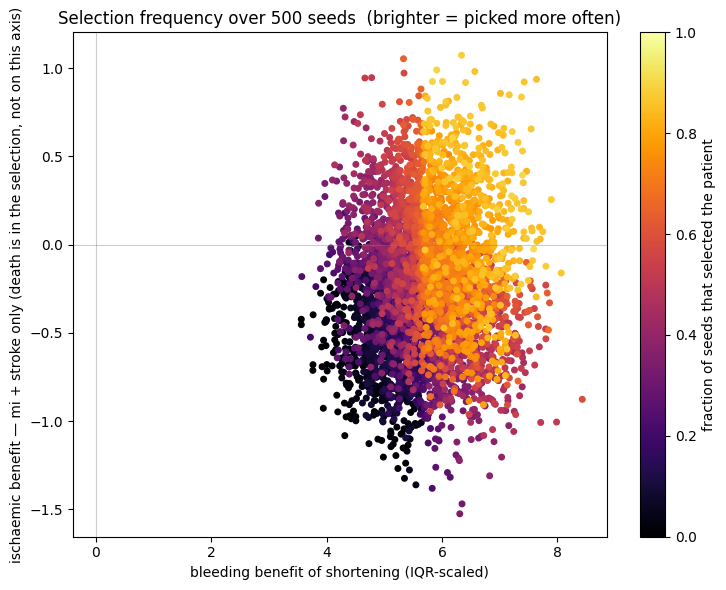

500 seeds, 2000 selected each   mean freq=0.44
always picked (freq=1): 0   never picked (freq=0): 12


In [9]:
# --- Same frequency map, projected on mi + stroke only ---
# death IS part of the selection (components_from_origin averages all three ischaemic
# endpoints weighted by ISCH_WEIGHTS) but it carries only 0.2 of the y axis; this second view
# drops it to show how much of the pattern above is held up by mi + stroke alone. Raw,
# uncentred units again, so the cohort keeps its position relative to the clinical zero. Only
# the projection changes: freq/order/picks are the ones computed in the cell above, so the
# frequencies themselves are identical.
#
# The decision vertex is NOT redrawn here: dropping death changes the y axis, so the median of
# this projection is not the coordinate the duels used. Only the clinical zero is marked.

mi_stroke_weights = {k: ISCH_WEIGHTS[k] for k in ('mi', 'stroke')}
isch_ms = weighted_isch(conflict, mi_stroke_weights)

fig, ax = plt.subplots(figsize=(7.6, 6))
sc = ax.scatter(conflict['bleed'].iloc[order], isch_ms.iloc[order], c=freq[order], s=16,
                cmap='inferno', vmin=0, vmax=1)
ax.axhline(0, color='grey', lw=.8, alpha=.4)
ax.axvline(0, color='grey', lw=.8, alpha=.4)
ax.set_xlim(left=-0.4)
ax.set(xlabel='bleeding benefit of shortening (IQR-scaled)',
       ylabel='ischaemic benefit — mi + stroke only (death is in the selection, not on this axis)',
       title=f'Selection frequency over {N_SEEDS} seeds  (brighter = picked more often)')
fig.colorbar(sc, ax=ax, label='fraction of seeds that selected the patient')
plt.tight_layout()
plt.show()

print(f'{N_SEEDS} seeds, {len(picks)} selected each   mean freq={freq.mean():.2f}')
print(f'always picked (freq=1): {int((freq == 1).sum())}   never picked (freq=0): {int((freq == 0).sum())}')